# VWAP Trend — Implementation Comparison

Loads standardized signal trades from `results/vwap_trend_trades.csv`
and tests multiple sizing implementations.

**Note:** VWAP Trend has no stop_price — risk-based sizing uses fallback.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _shared.implementations import (
    simple_bet, risk_based, kelly_sizing, vol_targeting, compare_implementations
)

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "VWAP Trend"

pd.set_option("display.max_columns", None)

## 2. Load Signal Trades

In [2]:
trades = pd.read_csv("results/vwap_trend_trades.csv", parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades)} trades")
print(f"Period: {trades['entry_time'].iloc[0].date()} → {trades['exit_time'].iloc[-1].date()}")
print(f"Columns: {list(trades.columns)}")
print(f"Has stop_price: {trades['stop_price'].notna().sum()} / {len(trades)}")
print(f"Directions: {dict(trades['direction'].value_counts())}")
print(f"Exit reasons: {dict(trades['exit_reason'].value_counts())}")


Loaded 41289 trades
Period: 2016-01-04 → 2026-03-31
Columns: ['entry_time', 'exit_time', 'direction', 'instrument', 'entry_price', 'exit_price', 'pct_return_gross', 'exit_reason', 'stop_price']
Has stop_price: 0 / 41289
Directions: {'long': 20766, 'short': 20523}
Exit reasons: {'vwap_cross': 38716, 'eod': 2573}


## 3. Sizing Comparison

In [3]:
# ── Simple bet ──
r_simple = simple_bet(trades, bet_size=0.85, slippage=0.0)
# ── Risk-based (1×) ──
r_risk_1x = risk_based(trades, risk_pct=0.01, leverage=1, slippage=0.0)
# ── Kelly ──
r_kelly_half = kelly_sizing(trades, fraction=0.5, burn_in=100, slippage=0.0)
# ── Vol targeting ──
r_vol = vol_targeting(trades, target_vol=0.10, lookback=60, slippage=0.0)

base_results = [r_simple, r_risk_1x, r_kelly_half, r_vol]
print("ALL IMPLEMENTATIONS:")
compare_implementations(base_results)

ALL IMPLEMENTATIONS:

Implementation                      Return       CAGR       Sharpe     Sortino    MaxDD      WinRate    PF        
Simple (85% bet)                       117.7%      7.9%      0.62      0.91     -27.5%     16.1%     1.05
Risk-based (1% risk, 1× lev)           144.3%      9.1%      0.62      0.91     -31.6%     16.1%     1.05
Half Kelly (burn-in=100)                -0.1%     -0.0%     -0.48     -0.04      -0.1%      0.0%     0.55
Vol target (10% ann, 2× max lev)       714.3%     22.7%      0.97      1.62     -46.4%     16.1%     1.07


## 4. Equity Curves

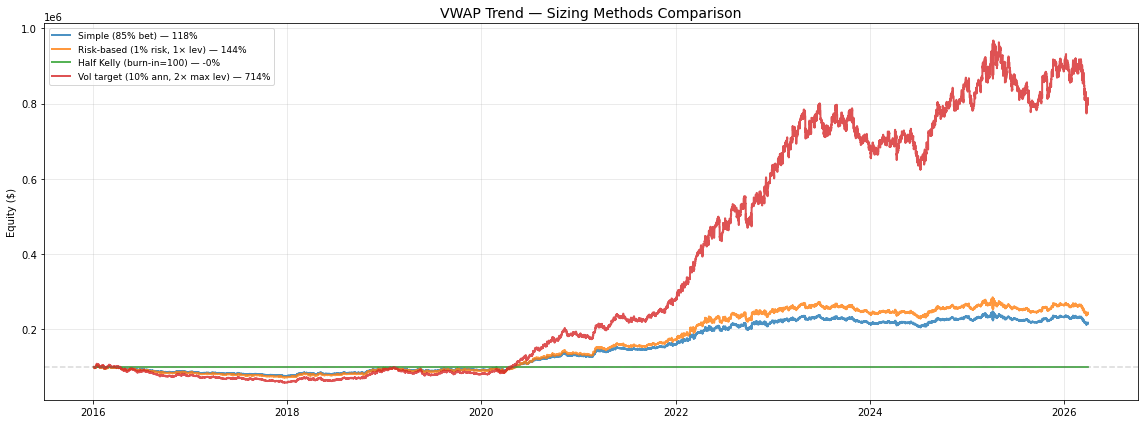

In [4]:
dates = [trades["entry_time"].iloc[0]] + trades["exit_time"].tolist()

fig, ax = plt.subplots(figsize=(16, 6))

for r in base_results:
    eq = r["equity_curve"]
    ret = (eq[-1] / STARTING_CAPITAL - 1) * 100
    ax.plot(dates[:len(eq)], eq, linewidth=2, alpha=0.8,
            label=f"{r['label']} — {ret:,.0f}%")

ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Sizing Methods Comparison", fontsize=14)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

## 5. Save Implementation Stats

In [5]:
import json

impl_summary = {}

for r in base_results:
    key = r["label"].lower().replace(" ", "_").replace("(", "").replace(")", "")\
         .replace("%", "pct").replace("=", "").replace(",", "").replace("×", "x")
    impl_summary[key] = r["stats"]
    impl_summary[key]["label"] = r["label"]

all_results = base_results
# Recommended: best Sharpe with MaxDD > -50%
viable = [r for r in all_results if r["stats"]["max_dd"] > -50]
if viable:
    best = max(viable, key=lambda r: r["stats"]["sharpe"])
    impl_summary["_recommended"] = best["label"]
    print(f"Recommended: {best['label']}")
    print(f"  Sharpe={best['stats']['sharpe']}, Return={best['stats']['total_return']}%, MaxDD={best['stats']['max_dd']}%")

with open("results/vwap_trend_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved {len(impl_summary) - 1} implementations → results/vwap_trend_implementations.json")

Recommended: Vol target (10% ann, 2× max lev)
  Sharpe=0.93, Return=714.3%, MaxDD=-46.4%

Saved 4 implementations → results/vwap_trend_implementations.json
